# ARIMA Analysis: SPY Daily Close Prices
# financial-ts-models | Cole McLeod
# March 7, 2026

In [1]:
# Cell 1: Setup and data pull
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

spy = yf.download('SPY', start='2019-01-01', end='2025-01-01')
close = spy['Close'].squeeze()
print(f'Observations: {len(close)}')
print(f'Date range: {close.index[0].date()} to {close.index[-1].date()}')

[*********************100%***********************]  1 of 1 completed

Observations: 1510
Date range: 2019-01-02 to 2024-12-31


## 1. Raw Series
Plot the raw price series. We expect a visible upward trend with drawdowns 
(COVID March 2020, 2022 bear market). A trending series is non-stationary 
because the mean changes over time. ARIMA requires stationarity, so this 
plot is our visual confirmation that we need to difference the data.

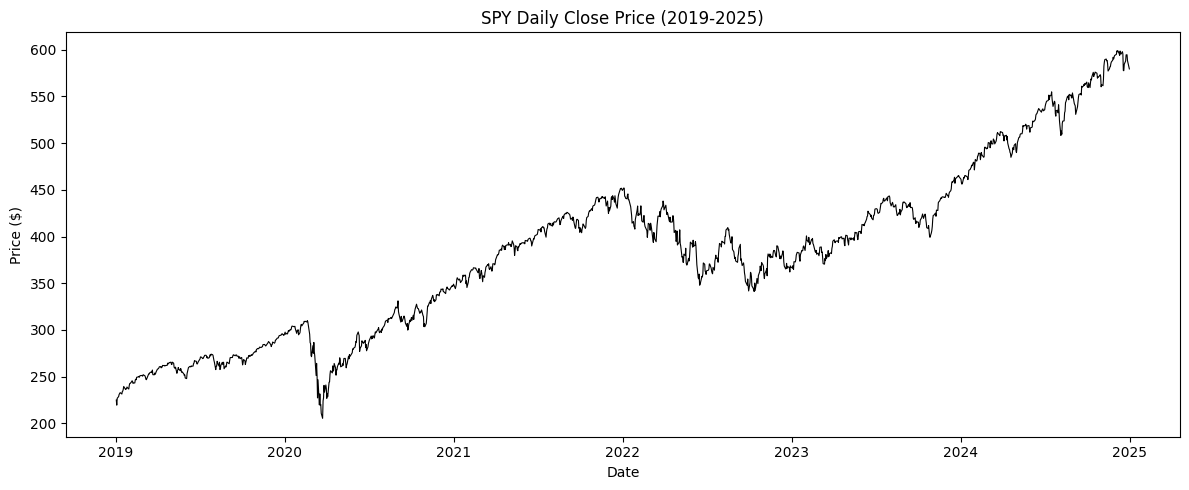

In [8]:
# Cell 2: Raw series plot
import os
os.makedirs('../figures', exist_ok=True)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(close, color='black', linewidth=0.8)
ax.set_title('SPY Daily Close Price (2019-2025)')
ax.set_ylabel('Price ($)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.savefig('../figures/01_ra|w_series.png',dpi=150)
plt.show()

## 2. ADF Test on Levels
The Augmented Dickey-Fuller test formally tests for a unit root.

- Null hypothesis: the series has a unit root (non-stationary). Shocks are 
  permanent. The series does not revert to a mean.
- Alternative: the series is stationary.

We expect to FAIL to reject the null here (p > 0.05). Raw prices are 
non-stationary.

In [9]:
# Cell 3: ADF test on levels
adf_levels = adfuller(close.dropna(), autolag='AIC')
print('ADF Test: SPY Close (Levels)')
print(f'  Test Statistic: {adf_levels[0]:.4f}')
print(f'  p-value:        {adf_levels[1]:.4f}')
print(f'  Lags Used:      {adf_levels[2]}')
print(f'  Conclusion:     {"Stationary" if adf_levels[1] < 0.05 else "Non-stationary"}')

ADF Test: SPY Close (Levels)
  Test Statistic: -0.2429
  p-value:        0.9332
  Lags Used:      10
  Conclusion:     Non-stationary


## 3. First Differencing
Compute y_t - y_{t-1} to convert prices to daily price changes. This 
removes the trend. The differenced series should fluctuate around a constant 
mean (near zero) with no visible drift.

We then run ADF again. This time we expect to REJECT the null (p < 0.05), 
confirming stationarity. This tells us d=1 in our ARIMA(p,d,q) model.

Note: stationarity requires constant mean and constant variance. The 
differenced series will show volatility clustering (larger moves clustered 
together during COVID, 2022). This violates the constant variance assumption 
and is exactly what GARCH addresses in the next notebook. ARIMA ignores it.

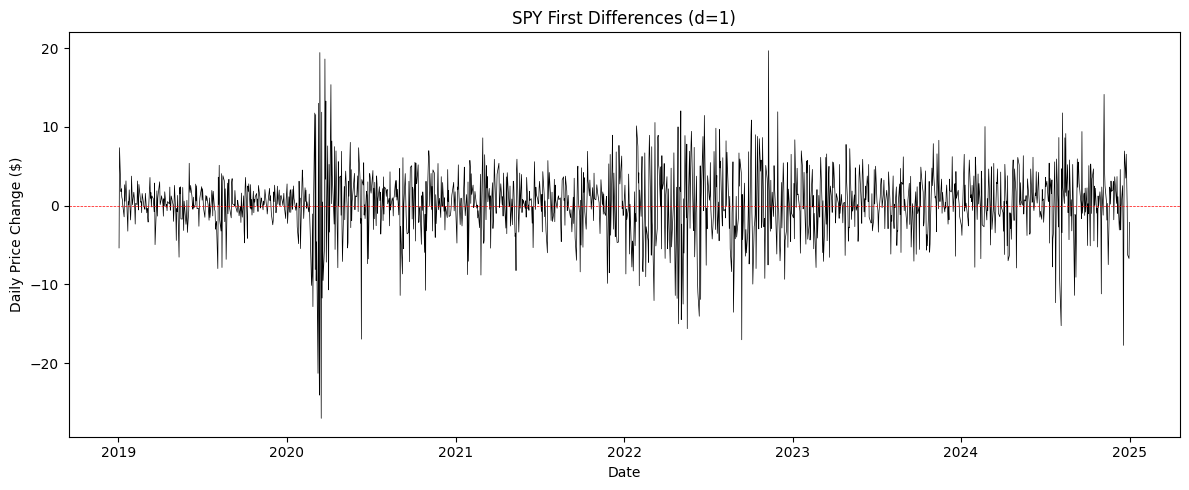

ADF Test: SPY First Differences
  Test Statistic: -12.1952
  p-value:        0.0000
  Conclusion:     Stationary


In [10]:
# Cell 4: First difference + ADF
diff = close.diff().dropna()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(diff, color='black', linewidth=0.5)
ax.set_title('SPY First Differences (d=1)')
ax.set_ylabel('Daily Price Change ($)')
ax.set_xlabel('Date')
ax.axhline(y=0, color='red', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.savefig('../figures/02_first_differences.png', dpi=150)
plt.show()

adf_diff = adfuller(diff, autolag='AIC')
print('ADF Test: SPY First Differences')
print(f'  Test Statistic: {adf_diff[0]:.4f}')
print(f'  p-value:        {adf_diff[1]:.4f}')
print(f'  Conclusion:     {"Stationary" if adf_diff[1] < 0.05 else "Non-stationary"}')

## 4. ACF and PACF
These plots help us identify candidate values for p (AR order) and q (MA order).

Reading the plots:
- ACF cuts off after lag q, PACF decays gradually -> MA(q) process
- PACF cuts off after lag p, ACF decays gradually -> AR(p) process
- Both decay gradually -> mixed ARMA(p,q), use AIC to select

Only spikes OUTSIDE the blue confidence band are statistically significant.

For SPY daily data, we expect very little significant autocorrelation. 
Financial returns on liquid indices are hard to predict with linear models. 
This is consistent with market efficiency at the daily frequency.

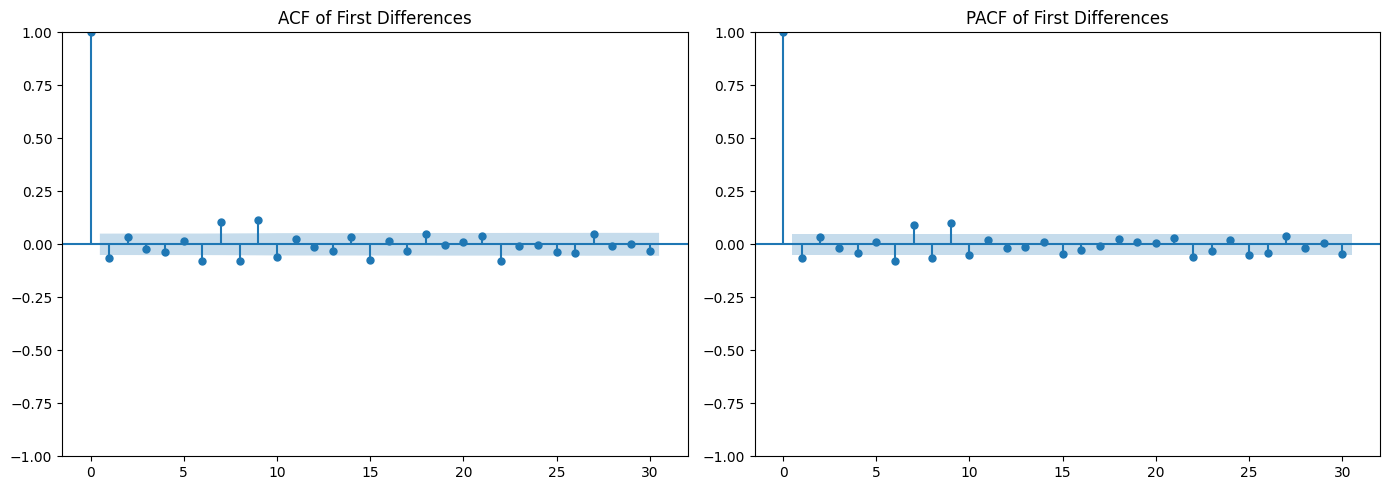

In [11]:
# Cell 5: ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(diff, lags=30, ax=axes[0], title='ACF of First Differences')
plot_pacf(diff, lags=30, method='ywm', ax=axes[1], title='PACF of First Differences')
plt.tight_layout()
plt.savefig('../figures/03_acf_pacf.png', dpi=150)
plt.show()

## 5. Model Comparison
Fit multiple ARIMA specifications and compare using information criteria.

- AIC = -2*ln(L) + 2k. Balances fit vs complexity. Lower is better.
- BIC = -2*ln(L) + k*ln(n). Penalizes complexity harder than AIC.

When AIC and BIC agree, the choice is clear. When they disagree, favor 
the simpler model (BIC's choice) unless AIC strongly favors the complex 
model (difference > 10).

We test pure AR, pure MA, and mixed ARMA specifications, all with d=1.

In [12]:
# Cell 6: Model comparison
orders = [(1,1,0), (0,1,1), (1,1,1), (2,1,1), (2,1,0), (0,1,2)]
results = []

for order in orders:
    try:
        model = ARIMA(close, order=order).fit()
        results.append({
            'Order': f'ARIMA{order}',
            'AIC': round(model.aic, 2),
            'BIC': round(model.bic, 2),
            'Log-Likelihood': round(model.llf, 2)
        })
    except Exception as e:
        results.append({
            'Order': f'ARIMA{order}',
            'AIC': None,
            'BIC': None,
            'Log-Likelihood': None
        })

comparison = pd.DataFrame(results).set_index('Order').sort_values('AIC')
print('Model Comparison (sorted by AIC):')
print(comparison.to_string())
print(f'\nBest by AIC: {comparison.index[0]}')
print(f'Best by BIC: {comparison.sort_values("BIC").index[0]}')

Model Comparison (sorted by AIC):
                    AIC      BIC  Log-Likelihood
Order                                           
ARIMA(1, 1, 0)  8647.49  8658.13        -4321.75
ARIMA(2, 1, 0)  8647.53  8663.48        -4320.76
ARIMA(0, 1, 2)  8647.67  8663.63        -4320.84
ARIMA(0, 1, 1)  8647.90  8658.54        -4321.95
ARIMA(1, 1, 1)  8647.97  8663.93        -4320.99
ARIMA(2, 1, 1)  8649.40  8670.68        -4320.70

Best by AIC: ARIMA(1, 1, 0)
Best by BIC: ARIMA(1, 1, 0)


## 6. Best Model Summary
Fit the winning model and inspect the full output.

Key things to check:
- Are AR and MA coefficients statistically significant (p < 0.05)?
- sigma^2 is the residual variance (what the model cannot explain)
- AR roots outside the unit circle confirms model stability

In [13]:
# Cell 7: Best model summary
# UPDATE THIS based on Cell 6 results
best_order = (1, 1, 1)
best_model = ARIMA(close, order=best_order).fit()
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:                    SPY   No. Observations:                 1510
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4320.987
Date:                Sun, 08 Mar 2026   AIC                           8647.975
Time:                        12:09:22   BIC                           8663.932
Sample:                             0   HQIC                          8653.918
                               - 1510                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3864      0.183     -2.108      0.035      -0.746      -0.027
ma.L1          0.3216      0.190      1.697      0.090      -0.050       0.693
sigma2        17.9765      0.399     45.095      0.0

## 7. Residual Diagnostics
If the model is adequate, residuals should be white noise: no remaining 
autocorrelation, no patterns over time.

plot_diagnostics gives 4 plots:
1. Standardized residuals over time: should look like random noise around 
   zero. Volatility clustering will be visible (COVID, 2022) because ARIMA 
   does not model conditional variance.
2. Histogram + KDE: should look roughly normal. Fat tails are expected for 
   financial data (same phenomenon as the Heston vs Gaussian chart).
3. Q-Q plot: points should follow the diagonal. Deviations in the tails 
   mean fat tails (leptokurtosis).
4. Correlogram: ACF of residuals. All spikes inside the band means no 
   remaining linear autocorrelation.

Ljung-Box test formalizes the correlogram check:
- Null: residuals are white noise (no autocorrelation)
- p > 0.05: residuals are white noise. Model is adequate.
- p < 0.05: residuals still have structure. Model is missing something.

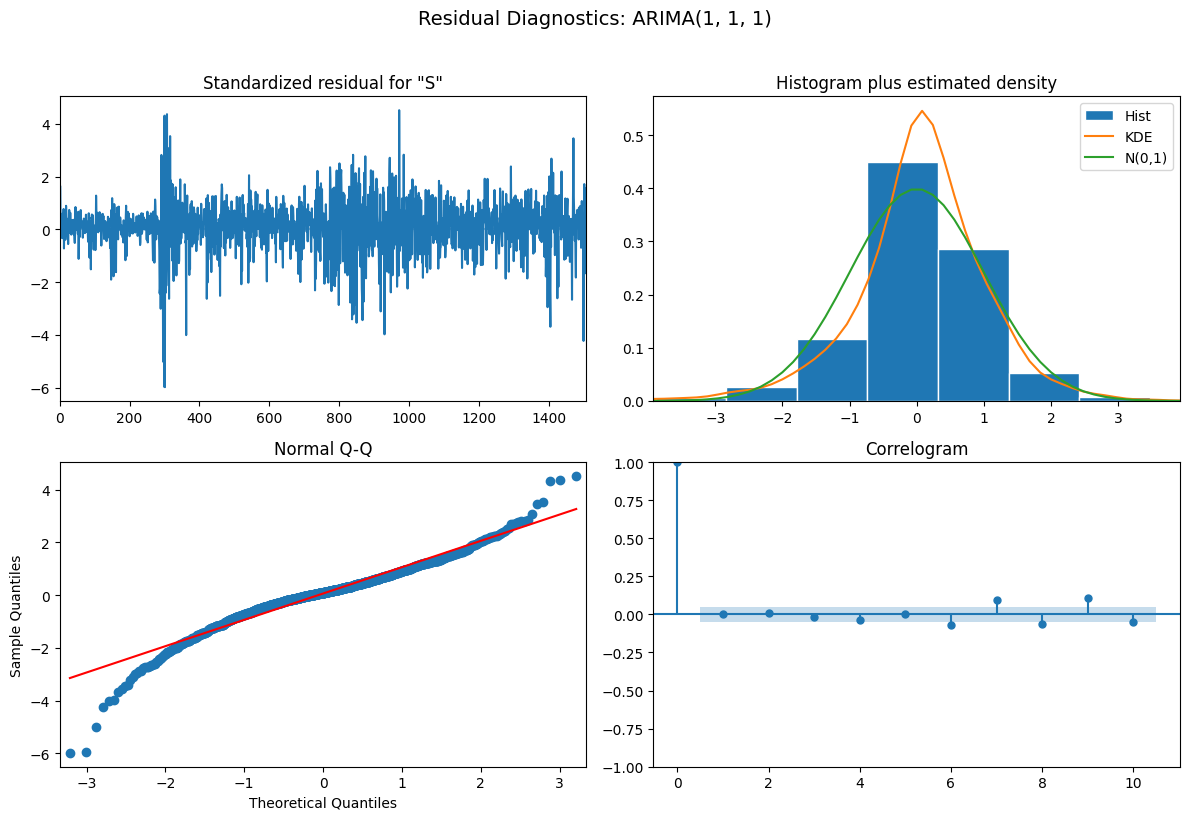

Ljung-Box Test (residual autocorrelation):
      lb_stat  lb_pvalue
10   7.966705   0.632089
20  11.021258   0.945669

p > 0.05 = white noise (model adequate)
p < 0.05 = structure remains (model inadequate)


In [14]:
# Cell 8: Residual diagnostics
fig = best_model.plot_diagnostics(figsize=(12, 8))
fig.suptitle(f'Residual Diagnostics: ARIMA{best_order}', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('../figures/04_residual_diagnostics.png', dpi=150)
plt.show()

lb = acorr_ljungbox(best_model.resid, lags=[10, 20], return_df=True)
print('Ljung-Box Test (residual autocorrelation):')
print(lb.to_string())
print('\np > 0.05 = white noise (model adequate)')
print('p < 0.05 = structure remains (model inadequate)')

## 8. Bridge to GARCH
ARIMA models the conditional mean of the series. But the residuals will 
show volatility clustering: periods of large residuals followed by periods 
of large residuals, and calm periods followed by calm periods.

If we squared the residuals and tested for autocorrelation, we would find 
significant structure. This is the conditional variance that ARIMA ignores.

GARCH models this directly. The next notebook (02_garch.ipynb) will take 
the residuals from this ARIMA model and fit a GARCH(1,1) to capture the 
time-varying variance. This connects to the Heston-Nandi GARCH framework 
in Escobar-Anel (2022).

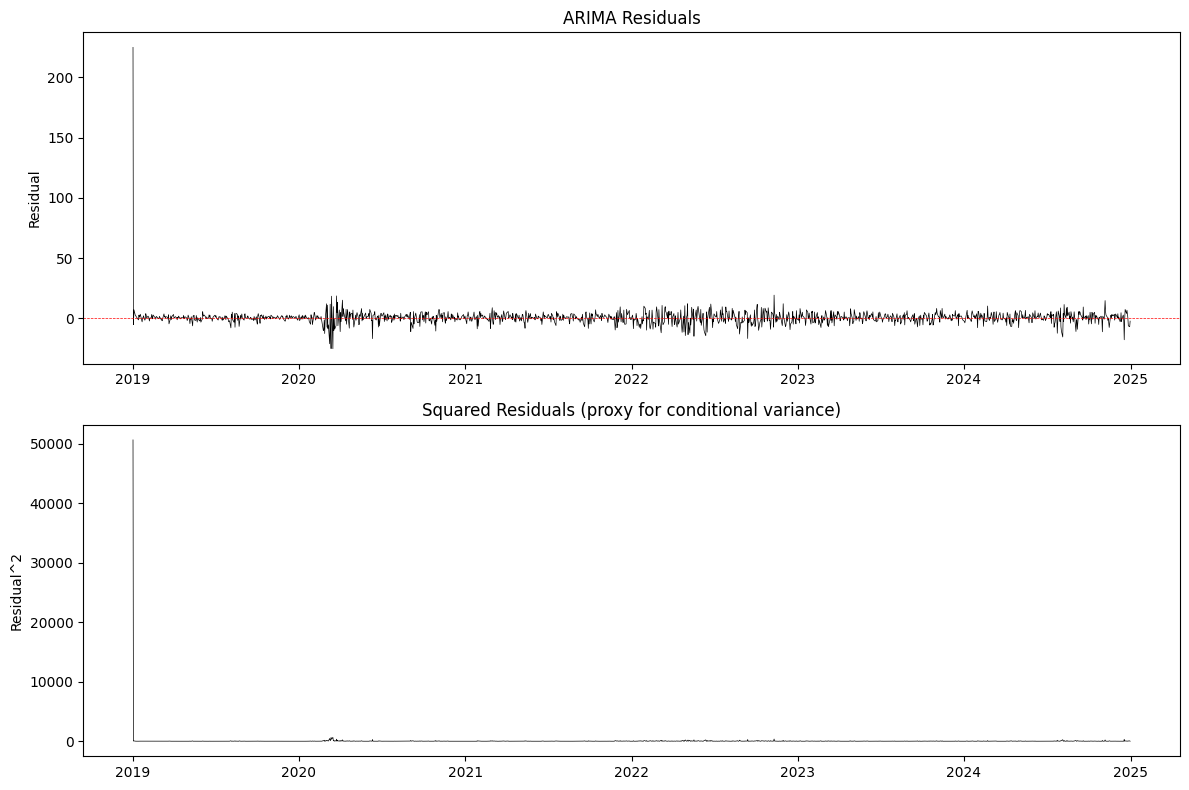

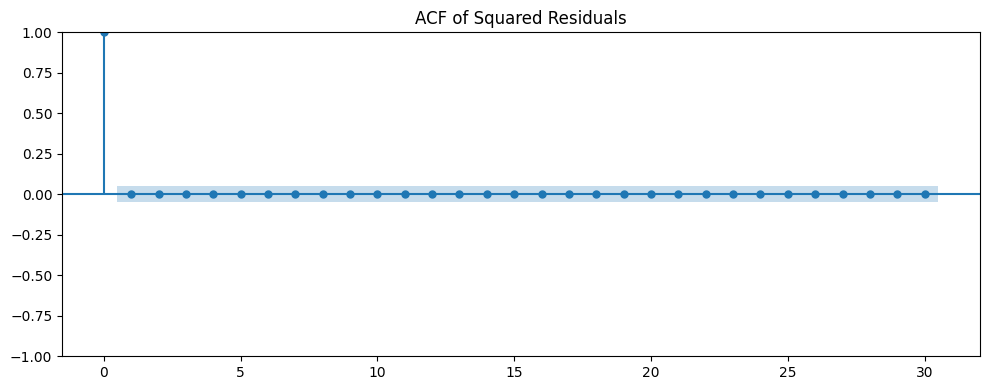

Significant autocorrelation in squared residuals = volatility clustering
This is what GARCH captures in the next notebook.


In [15]:
# Cell 9: Preview of volatility clustering in residuals
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(best_model.resid, color='black', linewidth=0.5)
axes[0].set_title('ARIMA Residuals')
axes[0].set_ylabel('Residual')
axes[0].axhline(y=0, color='red', linewidth=0.5, linestyle='--')

axes[1].plot(best_model.resid ** 2, color='black', linewidth=0.5)
axes[1].set_title('Squared Residuals (proxy for conditional variance)')
axes[1].set_ylabel('Residual^2')

plt.tight_layout()
plt.savefig('../figures/05_volatility_clustering.png', dpi=150)
plt.show()

# ACF of squared residuals
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(best_model.resid ** 2, lags=30, ax=ax, title='ACF of Squared Residuals')
plt.tight_layout()
plt.savefig('../figures/06_squared_resid_acf.png', dpi=150)
plt.show()

print('Significant autocorrelation in squared residuals = volatility clustering')
print('This is what GARCH captures in the next notebook.')